<a href="https://colab.research.google.com/github/umair594/Data-Science_Projects/blob/main/Real%20Estate%20Property%20Scraping%20and%20visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Real Estate Property Scraping and visualization**

**Introduction**

The real estate market is a critical sector that reflects economic conditions and investment opportunities. This project focuses on analyzing real estate property listings using a dataset obtained through web scraping. The goal is to clean, analyze, and visualize the data to extract meaningful insights about property prices, types, and locations.

**Objectives**

The main objectives of this project are:

To clean and preprocess raw scraped real estate data
To perform exploratory data analysis (EDA)
To visualize key trends in property pricing
To identify relationships between variables such as price, surface area, and number of rooms
To generate actionable insights for buyers, sellers, and investors

# **Understand the Dataset**

**Your dataset contains these key fields:**

Date → listing date

Rent/Buy → property type (Rent/Sale)

Where, Address, ZipCode → location

Type → apartment/house/etc.

NbOfRooms → number of rooms

Surface → size (likely m²)

Floor → floor level

Price → price (CHF format)

Source → website

**Data Collection**

The dataset was obtained through web scraping from real estate listing platforms. The scraped data initially contained inconsistencies such as special characters, missing values, and non-numeric formats.

# **Step 1: Upload File in Colab**

In [11]:
from google.colab import files
uploaded = files.upload()

Saving Output.csv to Output (1).csv


# **Step 2: Import Libraries**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **Step 3: Load Dataset**

In [15]:
df = pd.read_csv('Output.csv', encoding='latin1')
df.head()

,Unnamed: 0,Date,Rent/Buy,Where,Address,ZipCode,Description,Type,NbOfRooms,Surface,Floor,Price,Source
0,1,17/03/2017,Rent,Lausanne,Rue Petit-Saint-Jean1,1003 Lausanne,Superbe studio fraîchement rénové - hyper cent...,Appartement,1.0,30 m2,2.,CHF 940.,Immostreet
1,2,17/03/2017,Rent,Lausanne,NaN,1003 Lausanne,"A louer, Rue de la Mercerie 16 à Lausanne, jol...",Studio,1.0,19 m2,2.,CHF 950.,Immostreet
2,3,17/03/2017,Rent,Lausanne,Rue St-Laurent 29,1003 Lausanne,"Au coeur de la ville, dans la zone piétonnière...",Studio,1.0,NaN,1.,CHF 1'010.,Immostreet
3,4,17/03/2017,Rent,Lausanne,Place Chauderon 30,1003 Lausanne,"1 chambre, cuisine avec réchaud 2 plaques, réf...",Studio,1.0,21 m2,5.,CHF 1'200.,Immostreet
4,5,17/03/2017,Rent,Lausanne,Ruelle de Bourg 11,1003 Lausanne,Situé proche de toutes commodités et des trans...,Appartement,2.5,44 m2,NaN,CHF 1'990.,Immostreet


**Data Cleaning and Preprocessing**

Data preprocessing was a crucial step to ensure accuracy in analysis. The following operations were performed:

**Handling Missing Values**

Removed rows with missing values in critical columns such as Price, Surface, and Number of Rooms

**Data Formatting**

Converted Price from string (e.g., "CHF 1'200.–") to numeric format

Cleaned Surface by removing units ("m2")
Converted NbOfRooms to numeric
Converted Date to datetime format

**Feature Engineering**

Created a new feature:
Price_per_m2 = Price / Surface

# **Step 4: Clean Dataset (FIXED VERSION)**

In [16]:
# Drop unwanted column safely
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Clean Price
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace('CHF', '', regex=False)
df['Price'] = df['Price'].str.replace("'", '', regex=False)
df['Price'] = df['Price'].str.replace('.–', '', regex=False)
df['Price'] = df['Price'].str.replace('.', '', regex=False)
df['Price'] = df['Price'].str.strip()

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Clean Surface
df['Surface'] = df['Surface'].astype(str)
df['Surface'] = df['Surface'].str.replace('m2', '', regex=False)
df['Surface'] = pd.to_numeric(df['Surface'], errors='coerce')

# Clean Rooms
df['NbOfRooms'] = pd.to_numeric(df['NbOfRooms'], errors='coerce')

# Clean Date
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

/tmp/ipykernel_1239/3673670742.py:24: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


# **Step 5: Check Data (IMPORTANT)**

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         410 non-null    datetime64[ns]
 1   Rent/Buy     410 non-null    object        
 2   Where        410 non-null    object        
 3   Address      398 non-null    object        
 4   ZipCode      410 non-null    object        
 5   Description  410 non-null    object        
 6   Type         410 non-null    object        
 7   NbOfRooms    400 non-null    float64       
 8   Surface      361 non-null    float64       
 9   Floor        365 non-null    object        
 10  Price        405 non-null    float64       
 11  Source       410 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(8)
memory usage: 38.6+ KB


In [18]:
# check missing vakues
df.isnull().sum()

,0
Date,0
Rent/Buy,0
Where,0
Address,12
ZipCode,0
Description,0
Type,0
NbOfRooms,10
Surface,49
Floor,45


# **Step 6: Drop Missing Values (to avoid errors)**

In [19]:
df = df.dropna(subset=['Price', 'Surface', 'NbOfRooms'])

In [20]:
# Check missing values
df.isnull().sum()

,0
Date,0
Rent/Buy,0
Where,0
Address,9
ZipCode,0
Description,0
Type,0
NbOfRooms,0
Surface,0
Floor,27


In [21]:
df = df.dropna(subset=['Floor', 'Address'])

In [22]:
#Again Check missing values
df.isnull().sum()

,0
Date,0
Rent/Buy,0
Where,0
Address,0
ZipCode,0
Description,0
Type,0
NbOfRooms,0
Surface,0
Floor,0


**Exploratory Data Analysis (EDA)**

**Summary Statistics**

The dataset shows a wide variation in property prices
Most listings fall within a moderate price range, with some high-end outliers

**Property Type Distribution**

Apartments are the most common property type
Houses and other property types appear less frequently

**Rent vs Buy Analysis**

The dataset includes both rental and sale properties
Rental listings are generally more frequent

# **Step 7: Basic Analysis**

In [23]:
print("Average Price:", df['Price'].mean())

print("\nProperty Types:\n", df['Type'].value_counts())

print("\nRent vs Buy:\n", df['Rent/Buy'].value_counts())

Average Price: 2450.846875

Property Types:
 Type
Appartement     291
Studio           15
Attique           5
Duplex            3
Loft              3
Chambre           2
App. intégré      1
Name: count, dtype: int64

Rent vs Buy:
 Rent/Buy
Rent    320
Name: count, dtype: int64


**Data Visualization**

Several visualizations were created to better understand the data:

**Price Distribution**

A histogram shows that most properties fall within a certain price range
The distribution is right-skewed due to expensive properties

**Average Price by Property Type**

Houses generally have higher average prices than apartments

**Price by Location**

Certain locations have significantly higher average prices
Indicates high-demand or premium areas

**Price vs Surface Area**

A positive correlation exists between surface area and price
Larger properties tend to be more expensive

# **Step 8: Visualization (ERROR-FREE)**

**Price Distribution**

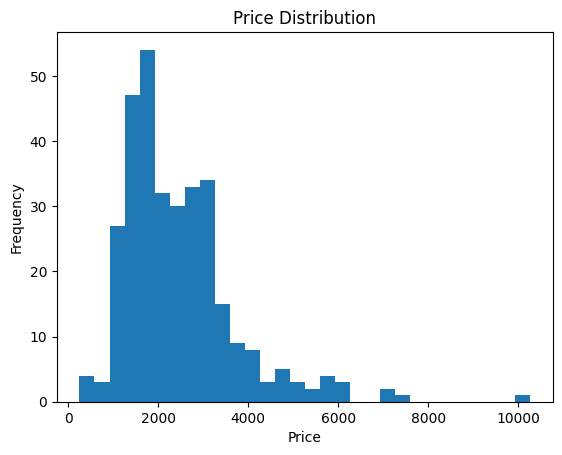

In [24]:
plt.figure()
plt.hist(df['Price'], bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

**Price by Property Type**

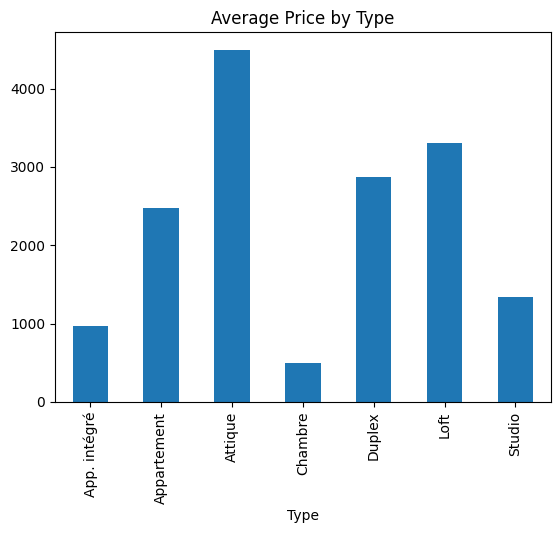

In [25]:
plt.figure()
df.groupby('Type')['Price'].mean().plot(kind='bar')
plt.title("Average Price by Type")
plt.show()

**Price vs Surface**

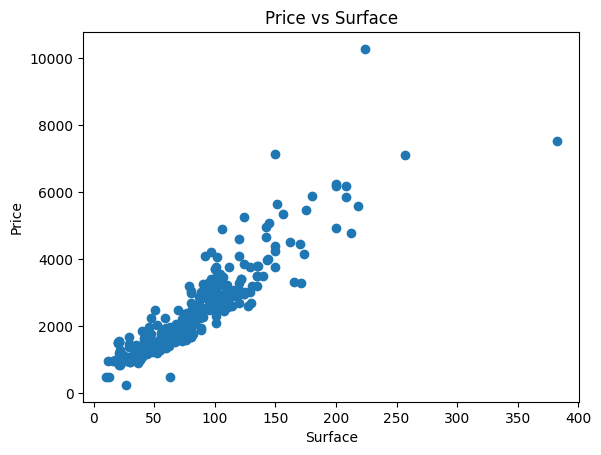

In [26]:
plt.figure()
plt.scatter(df['Surface'], df['Price'])
plt.xlabel("Surface")
plt.ylabel("Price")
plt.title("Price vs Surface")
plt.show()

# **Step 9: Feature Engineering**

In [27]:
df['Price_per_m2'] = df['Price'] / df['Surface']
df.head()

,Date,Rent/Buy,Where,Address,ZipCode,Description,Type,NbOfRooms,Surface,Floor,Price,Source,Price_per_m2
0,2017-03-17,Rent,Lausanne,Rue Petit-Saint-Jean1,1003 Lausanne,Superbe studio fraîchement rénové - hyper cent...,Appartement,1.0,30.0,2.,940.0,Immostreet,31.333333
3,2017-03-17,Rent,Lausanne,Place Chauderon 30,1003 Lausanne,"1 chambre, cuisine avec réchaud 2 plaques, réf...",Studio,1.0,21.0,5.,1200.0,Immostreet,57.142857
5,2017-03-17,Rent,Lausanne,Rue St-Laurent 12,1003 Lausanne,Charmant appartement de 3 pièces lumineux au c...,Appartement,3.0,73.0,5.,2000.0,Immostreet,27.397260
6,2017-03-17,Rent,Lausanne,Rue Charles Monnard 6,1003 Lausanne,Bel appartement avec cuisine agencée (lave-vai...,Appartement,3.5,99.0,2.,2505.0,Immostreet,25.303030
7,2017-03-17,Rent,Lausanne,Rue Saint-Martin 25,1003 Lausanne,"Nous proposons à la location, un magnifique ap...",Duplex,3.5,109.0,1.,2630.0,Immostreet,24.128440


# **Key Insights**

Surface area is a major factor influencing price

Location significantly impacts property value

Apartments dominate the market, but houses are priced higher

Price per square meter varies across locations, indicating
investment opportunities

The dataset contains some outliers (luxury properties) that affect averages

# **Conclusion**

This project successfully demonstrates how raw scraped real estate data can be transformed into meaningful insights through data cleaning, analysis, and visualization.

**The findings highlight:**

The importance of property size and location in pricing
Market trends that can assist buyers and investors
Opportunities for further predictive modeling

# **References**

Real estate listing websites (data source)

Python documentation

Data analysis and visualization libraries